# Multi-Source Evidence Pipeline: Alzheimer's Disease Comparison

**Trials under analysis:**
1. **NCT03887455** · Clarity AD — Lecanemab (Eisai / Biogen) — Phase 3 · N=1,795  
   *"A Study to Confirm Safety and Efficacy of Lecanemab in Participants With Early Alzheimer's Disease"*

2. **NCT00348140** · Rosiglitazone Extended Release — GlaxoSmithKline — Phase 3 · N=1,468  
   *"Rosiglitazone (XR Tablets) As Adjunctive Therapy In Subjects With Mild To Moderate Alzheimer's Disease"*

---
**Pipeline:** ClinicalTrials.gov API → PubMed Literature → FDA OpenFDA → Evidence Gap Analysis → Spin Detection → AI Intelligence Card


## 1. Imports & Configuration

In [1]:
import json
import math
import os
import time
import urllib.parse
import urllib.request
import urllib.error
from datetime import datetime
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, HTML, Markdown

load_dotenv()

# ── Style ────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'axes.titlecolor':  '#e6edf3',
    'grid.color':       '#21262d',
    'axes.edgecolor':   '#30363d',
})

PALETTE = {
    'NCT03887455': '#58a6ff',   # Lecanemab — blue
    'NCT00348140': '#ff7b72',   # Rosiglitazone — red
    'neutral':     '#8b949e',
    'success':     '#3fb950',
    'warning':     '#d29922',
    'danger':      '#da3633',
}

OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY', '')

# ── Target Trials ─────────────────────────────────────────────────────────
TRIALS = {
    'NCT03887455': {
        'drug_name':    'Lecanemab (BAN2401)',
        'brand_name':   'Leqembi',
        'sponsor':      'Eisai / Biogen',
        'indication':   "Alzheimer's Disease (Early)",
        'phase':        'Phase 3',
        'mechanism':    'Anti-amyloid beta protofibril monoclonal antibody',
        'pubmed_query': 'lecanemab clarity AD alzheimer phase 3 efficacy',
        'fda_brand':    'leqembi',
        'color':        PALETTE['NCT03887455'],
    },
    'NCT00348140': {
        'drug_name':    'Rosiglitazone (XR)',
        'brand_name':   'Avandia (XR formulation)',
        'sponsor':      'GlaxoSmithKline',
        'indication':   "Alzheimer's Disease (Mild-to-Moderate)",
        'phase':        'Phase 3',
        'mechanism':    'PPAR-γ agonist / insulin sensitizer',
        'pubmed_query': 'rosiglitazone alzheimer APOE4 phase 3 adjunctive',
        'fda_brand':    'avandia',
        'color':        PALETTE['NCT00348140'],
    },
}

print('✅ Configuration loaded.')
print(f'   OpenRouter API key: {"SET" if OPENROUTER_API_KEY else "NOT SET (AI cards will use template mode)"}')
print()
for nct, t in TRIALS.items():
    print(f'  [{nct}] {t["drug_name"]} ({t["brand_name"]}) — {t["sponsor"]}')


✅ Configuration loaded.
   OpenRouter API key: SET

  [NCT03887455] Lecanemab (BAN2401) (Leqembi) — Eisai / Biogen
  [NCT00348140] Rosiglitazone (XR) (Avandia (XR formulation)) — GlaxoSmithKline


## 2. ClinicalTrials.gov API — Registry Metadata

In [2]:
def fetch_ctgov(nct_id: str) -> dict:
    """Fetch full study record from ClinicalTrials.gov v2 API."""
    url = f'https://clinicaltrials.gov/api/v2/studies/{nct_id}'
    req = urllib.request.Request(url, headers={'Accept': 'application/json'})
    try:
        with urllib.request.urlopen(req, timeout=15) as resp:
            return json.loads(resp.read().decode())
    except urllib.error.HTTPError as e:
        print(f'  ⚠️  CTgov HTTP {e.code} for {nct_id}')
        return {}
    except Exception as e:
        print(f'  ⚠️  CTgov error for {nct_id}: {e}')
        return {}

def parse_ctgov(raw: dict, nct_id: str) -> dict:
    """Extract key fields from CTgov v2 JSON response."""
    if not raw:
        return {'nct_id': nct_id, 'error': 'fetch_failed'}

    ps  = raw.get('protocolSection', {})
    idm = ps.get('identificationModule', {})
    stm = ps.get('statusModule', {})
    dsm = ps.get('designModule', {})
    elm = ps.get('eligibilityModule', {})
    ctm = ps.get('contactsLocationsModule', {})
    rem = ps.get('resultsSection', {}) or {}
    oum = ps.get('outcomesModule', {}) or {}
    arm = ps.get('armsInterventionsModule', {}) or {}
    spm = ps.get('sponsorCollaboratorsModule', {}) or {}
    ovm = ps.get('oversightModule', {}) or {}

    # enrollment
    enrollment = dsm.get('enrollmentInfo', {})
    enroll_count = enrollment.get('count', 'N/A')

    # phases
    phases = dsm.get('phases', [])
    phase_str = ', '.join(phases) if phases else 'N/A'

    # primary outcomes
    primary_outcomes = oum.get('primaryOutcomes', [])
    primary_measures = [o.get('measure','') for o in primary_outcomes[:3]]

    # results posted?
    has_results = raw.get('hasResults', False)
    results_section = rem

    # safety — adverse events
    ae_module = results_section.get('adverseEventsModule', {})
    serious_aes = ae_module.get('seriousEvents', [])
    other_aes   = ae_module.get('otherEvents', [])

    # primary endpoint result from results section
    outcome_measures = results_section.get('outcomeMeasuresModule', {}).get('outcomeMeasures', [])
    primary_result = None
    for om in outcome_measures:
        if om.get('type','').lower() == 'primary':
            primary_result = om
            break

    return {
        'nct_id':           nct_id,
        'title':            idm.get('briefTitle', 'N/A'),
        'official_title':   idm.get('officialTitle', 'N/A'),
        'status':           stm.get('overallStatus', 'N/A'),
        'start_date':       stm.get('startDateStruct', {}).get('date', 'N/A'),
        'primary_completion': stm.get('primaryCompletionDateStruct', {}).get('date', 'N/A'),
        'study_completion': stm.get('completionDateStruct', {}).get('date', 'N/A'),
        'phase':            phase_str,
        'enrollment':       enroll_count,
        'study_type':       dsm.get('studyType', 'N/A'),
        'allocation':       dsm.get('designInfo', {}).get('allocation', 'N/A'),
        'masking':          dsm.get('designInfo', {}).get('maskingInfo', {}).get('masking', 'N/A'),
        'sponsor':          spm.get('leadSponsor', {}).get('name', 'N/A'),
        'has_results':      has_results,
        'primary_outcomes': primary_measures,
        'primary_result':   primary_result,
        'serious_ae_count': len(serious_aes),
        'other_ae_count':   len(other_aes),
        'fda_regulated_drug': ovm.get('isFdaRegulatedDrug', 'N/A'),
        'min_age':          elm.get('minimumAge', 'N/A'),
        'max_age':          elm.get('maximumAge', 'N/A'),
        'sex':              elm.get('sex', 'N/A'),
        'raw':              raw,
    }

# ── Fetch all trials ──────────────────────────────────────────────────────
ctgov_data = {}
for nct_id in TRIALS:
    print(f'Fetching {nct_id} from ClinicalTrials.gov...', end=' ')
    raw = fetch_ctgov(nct_id)
    ctgov_data[nct_id] = parse_ctgov(raw, nct_id)
    status = ctgov_data[nct_id].get('status', '?')
    has_r  = ctgov_data[nct_id].get('has_results', False)
    print(f'✅  Status={status}  HasResults={has_r}')
    time.sleep(0.5)


Fetching NCT03887455 from ClinicalTrials.gov... 

✅  Status=ACTIVE_NOT_RECRUITING  HasResults=False


Fetching NCT00348140 from ClinicalTrials.gov... 

✅  Status=COMPLETED  HasResults=True


In [3]:
# ── CTgov summary table ────────────────────────────────────────────────────
rows = []
fields = ['title','status','phase','enrollment','study_type','allocation',
          'masking','sponsor','start_date','primary_completion','study_completion',
          'has_results','serious_ae_count','other_ae_count']
for nct_id, d in ctgov_data.items():
    row = {'NCT ID': nct_id}
    for f in fields:
        row[f.replace('_',' ').title()] = d.get(f, 'N/A')
    rows.append(row)

ctgov_df = pd.DataFrame(rows).set_index('NCT ID').T
display(HTML('<h4 style="color:#58a6ff">ClinicalTrials.gov Registry Snapshot</h4>'))
display(ctgov_df.style.set_properties(**{
    'background-color': '#161b22',
    'color': '#e6edf3',
    'border': '1px solid #30363d',
    'padding': '6px 10px',
    'font-size': '13px',
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color','#21262d'),('color','#58a6ff'),('font-weight','bold'),('padding','8px 10px')]
}]))

# ── Flag no-results trials ──────────────────────────────────────────────────
print()
for nct_id, d in ctgov_data.items():
    drug = TRIALS[nct_id]['drug_name']
    if not d.get('has_results'):
        print(f'⚠️  EVIDENCE GAP: {nct_id} ({drug}) — NO RESULTS posted on ClinicalTrials.gov')
        print(f'   Status on CTgov: {d["status"]}  |  Primary completion: {d["primary_completion"]}')
        print(f'   → Evidence must be sought in published literature & regulatory documents.')
    else:
        print(f'✅  {nct_id} ({drug}) — Results section IS available on ClinicalTrials.gov')
    print()


NCT ID,NCT03887455,NCT00348140
Title,A Study to Confirm Safety and Efficacy of Lecanemab in Participants With Early Alzheimer's Disease,Rosiglitazone (Extended Release Tablets) As Adjunctive Therapy In Subjects With Mild To Moderate Alzheimer's Disease
Status,ACTIVE_NOT_RECRUITING,COMPLETED
Phase,PHASE3,PHASE3
Enrollment,1906,1468
Study Type,INTERVENTIONAL,INTERVENTIONAL
Allocation,RANDOMIZED,RANDOMIZED
Masking,QUADRUPLE,QUADRUPLE
Sponsor,Eisai Inc.,GlaxoSmithKline
Start Date,2019-03-27,2006-07-12
Primary Completion,2029-06-30,2009-03-20



⚠️  EVIDENCE GAP: NCT03887455 (Lecanemab (BAN2401)) — NO RESULTS posted on ClinicalTrials.gov
   Status on CTgov: ACTIVE_NOT_RECRUITING  |  Primary completion: 2029-06-30
   → Evidence must be sought in published literature & regulatory documents.

✅  NCT00348140 (Rosiglitazone (XR)) — Results section IS available on ClinicalTrials.gov



## 3. PubMed Literature Harvester

In [4]:
PUBMED_BASE = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils'

def pubmed_search(query: str, max_results: int = 8) -> list:
    """Search PubMed and return list of PMIDs."""
    params = urllib.parse.urlencode({
        'db': 'pubmed', 'term': query, 'retmax': max_results,
        'retmode': 'json', 'sort': 'relevance'
    })
    url = f'{PUBMED_BASE}/esearch.fcgi?{params}'
    try:
        with urllib.request.urlopen(url, timeout=10) as r:
            data = json.loads(r.read())
            return data.get('esearchresult', {}).get('idlist', [])
    except Exception as e:
        print(f'  PubMed search error: {e}')
        return []

def pubmed_fetch(pmids: list) -> list:
    """Fetch abstracts for a list of PMIDs."""
    if not pmids:
        return []
    ids = ','.join(pmids[:8])
    params = urllib.parse.urlencode({
        'db': 'pubmed', 'id': ids,
        'retmode': 'json', 'rettype': 'abstract'
    })
    url = f'{PUBMED_BASE}/esummary.fcgi?{params}'
    try:
        with urllib.request.urlopen(url, timeout=10) as r:
            data = json.loads(r.read())
            result = data.get('result', {})
            uids = result.get('uids', [])
            papers = []
            for uid in uids:
                p = result.get(uid, {})
                authors = [a.get('name','') for a in p.get('authors', [])[:3]]
                papers.append({
                    'pmid':    uid,
                    'title':   p.get('title', 'N/A'),
                    'journal': p.get('fulljournalname', p.get('source', 'N/A')),
                    'year':    p.get('pubdate', 'N/A')[:4],
                    'authors': ', '.join(authors) + (' et al.' if len(p.get('authors',[])) > 3 else ''),
                    'doi':     next((i.get('value','') for i in p.get('articleids',[]) if i.get('idtype')=='doi'), ''),
                })
            return papers
    except Exception as e:
        print(f'  PubMed fetch error: {e}')
        return []

# ── Run PubMed for each trial ──────────────────────────────────────────────
pubmed_data = {}
for nct_id, meta in TRIALS.items():
    drug = meta['drug_name']
    query = meta['pubmed_query']
    print(f'Searching PubMed for [{nct_id}] {drug}...')
    pmids = pubmed_search(query)
    # also search by NCT ID directly
    nct_pmids = pubmed_search(nct_id)
    all_pmids = list(dict.fromkeys(pmids + nct_pmids))[:8]
    papers = pubmed_fetch(all_pmids)
    pubmed_data[nct_id] = papers
    print(f'  Found {len(papers)} papers')
    time.sleep(0.4)


Searching PubMed for [NCT03887455] Lecanemab (BAN2401)...


  Found 8 papers


Searching PubMed for [NCT00348140] Rosiglitazone (XR)...


  Found 1 papers


In [5]:
# ── Display PubMed results ─────────────────────────────────────────────────
for nct_id, papers in pubmed_data.items():
    drug = TRIALS[nct_id]['drug_name']
    color = TRIALS[nct_id]['color']
    display(HTML(f'<h4 style="color:{color};margin-top:20px">{nct_id} — {drug}: Published Literature ({len(papers)} papers found)</h4>'))
    if not papers:
        display(HTML('<p style="color:#da3633">⚠️ No papers found on PubMed for this query.</p>'))
        continue
    rows = []
    for p in papers:
        doi_link = f'<a href="https://doi.org/{p["doi"]}" target="_blank">{p["doi"]}</a>' if p['doi'] else 'N/A'
        rows.append({
            'PMID': f'<a href="https://pubmed.ncbi.nlm.nih.gov/{p["pmid"]}/" target="_blank">{p["pmid"]}</a>',
            'Year': p['year'],
            'Authors': p['authors'],
            'Title': p['title'][:90] + ('...' if len(p['title']) > 90 else ''),
            'Journal': p['journal'],
            'DOI': doi_link,
        })
    df = pd.DataFrame(rows)
    display(HTML(df.to_html(escape=False, index=False, border=0, classes='pubmed-table')))
    print()


PMID,Year,Authors,Title,Journal,DOI
36449413,2023,"van Dyck CH, Swanson CJ, Aisen P et al.",Lecanemab in Early Alzheimer's Disease.,The New England journal of medicine,10.1056/NEJMoa2212948
37357276,2023,"Cummings J, Apostolova L, Rabinovici GD et al.",Lecanemab: Appropriate Use Recommendations.,The journal of prevention of Alzheimer's disease,10.14283/jpad.2023.30
41355080,2025,"van Dyck CH, Sperling R, Johnson K et al.",Long-term safety and efficacy of lecanemab in early Alzheimer's disease: Results from the ...,Alzheimer's & dementia : the journal of the Alzheimer's Association,10.1002/alz.70905
40189473,2025,"Chen C, Katayama S, Lee JH et al.",Clarity AD: Asian regional analysis of a phase III trial of lecanemab in early Alzheimer's...,The journal of prevention of Alzheimer's disease,10.1016/j.tjpad.2025.100160
41689888,2026,"Perry R, Kipps C, Soto Martín ME et al.",Lecanemab for treatment of individuals with early Alzheimer's Disease (AD) who are apolipo...,The journal of prevention of Alzheimer's disease,10.1016/j.tjpad.2026.100507
38001337,2024,"Lian Y, Jia YJ, Wong J et al.",Clarity on the blazing trail: clearing the way for amyloid-removing therapies for Alzheime...,Molecular psychiatry,10.1038/s41380-023-02324-4
40232258,2025,"Ashmawy RE, Okesanya OJ, Ukoaka BM et al.",Exploring the efficacy and safety of lecanemab in the management of early Alzheimer's dise...,Journal of Alzheimer's disease : JAD,10.1177/13872877251331640
36482412,2022,"Dhadda S, Kanekiyo M, Li D et al.",Consistency of efficacy results across various clinical measures and statistical methods i...,Alzheimer's research & therapy,10.1186/s13195-022-01129-x


PMID,Year,Authors,Title,Journal,DOI
21592048,2011,"Harrington C, Sawchak S, Chiang C et al.",Rosiglitazone does not improve cognition or global function when used as adjunctive therap...,Current Alzheimer research,10.2174/156720511796391935


## 3b. Extended Evidence Harvesting — 5 Additional Sources

> **Europe PMC · FDA FAERS · CrossRef/DOI · WHO ICTRP · OpenAlex**  



In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SOURCE 2b: Europe PMC — 48M+ papers incl. preprints
# API: https://www.ebi.ac.uk/europepmc/webservices/rest/
# Covers: PubMed + Agricola + EPO patents + NICE + preprints
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

EUROPE_PMC_BASE = 'https://www.ebi.ac.uk/europepmc/webservices/rest/search'

def europepmc_search(query: str, max_results: int = 8) -> list:
    params = urllib.parse.urlencode({
        'query': query, 'resulttype': 'lite',
        'format': 'json', 'pageSize': max_results, 'sort': 'RELEVANCE'
    })
    url = f'{EUROPE_PMC_BASE}?{params}'
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'MindReader/1.0'})
        with urllib.request.urlopen(req, timeout=12) as r:
            data = json.loads(r.read())
            results = data.get('resultList', {}).get('result', [])
            papers = []
            for p in results:
                papers.append({
                    'pmid':      p.get('pmid', ''),
                    'pmcid':     p.get('pmcid', ''),
                    'title':     p.get('title', 'N/A'),
                    'journal':   p.get('journalTitle', p.get('source', 'N/A')),
                    'year':      str(p.get('pubYear', 'N/A')),
                    'authors':   p.get('authorString', 'N/A')[:80],
                    'doi':       p.get('doi', ''),
                    'is_oa':     p.get('isOpenAccess', 'N') == 'Y',
                    'cited_by':  p.get('citedByCount', 0),
                    'source':    'Europe PMC',
                })
            return papers
    except Exception as e:
        print(f'  Europe PMC error: {e}')
        return []

epmc_data = {}
for nct_id, meta in TRIALS.items():
    drug  = meta['drug_name']
    query = f'{meta["drug_name"].split("(")[0].strip()} alzheimer efficacy trial'
    print(f'Europe PMC [{nct_id}] {drug}...', end=' ')
    papers = europepmc_search(query)
    epmc_data[nct_id] = papers
    oa_count = sum(1 for p in papers if p['is_oa'])
    print(f'✅ {len(papers)} papers ({oa_count} open access)')
    time.sleep(0.4)

print()
for nct_id, papers in epmc_data.items():
    drug = TRIALS[nct_id]['drug_name']
    color = TRIALS[nct_id]['color']
    display(HTML(f'<h5 style="color:{color}">[Europe PMC] {nct_id} — {drug}: {len(papers)} papers</h5>'))
    if papers:
        top = papers[:3]
        for p in top:
            oa_badge = '🔓 OA' if p['is_oa'] else '🔒'
            cite_str = f'📎 {p["cited_by"]} citations' if p['cited_by'] else ''
            link = f'https://doi.org/{p["doi"]}' if p['doi'] else f'https://europepmc.org/search?query={urllib.parse.quote(p["title"][:40])}'
            display(HTML(f'<div style="margin:4px 0;padding:6px 10px;background:#161b22;border-left:3px solid {color};border-radius:4px">'
                         f'<b><a href="{link}" target="_blank" style="color:#e6edf3">{p["title"][:80]}...</a></b><br>'
                         f'<span style="color:#8b949e;font-size:12px">{p["journal"]} · {p["year"]} · {p["authors"][:60]}... &nbsp;{oa_badge} {cite_str}</span></div>'))


Europe PMC [NCT03887455] Lecanemab (BAN2401)... 

✅ 0 papers (0 open access)


Europe PMC [NCT00348140] Rosiglitazone (XR)... 

✅ 0 papers (0 open access)


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SOURCE 3b: FDA FAERS — Real-World Post-Market Safety Signals
# FDA Adverse Event Reporting System (spontaneous reports from patients/HCPs)
# API: https://api.fda.gov/drug/event.json
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def fetch_fda_faers(drug_name: str, limit: int = 10) -> dict:
    """Fetch real-world adverse event reports from FDA FAERS."""
    # Search by active ingredient
    search_term = urllib.parse.quote(f'patient.drug.activesubstance.activesubstancename:{drug_name.upper()}')
    url = f'https://api.fda.gov/drug/event.json?search={search_term}&limit={limit}&count=patient.reaction.reactionmeddrapt.exact'
    try:
        with urllib.request.urlopen(url, timeout=12) as r:
            return json.loads(r.read())
    except urllib.error.HTTPError as e:
        if e.code == 404:
            return {'error': 'no_reports', 'results': []}
        return {'error': str(e)}
    except Exception as e:
        return {'error': str(e)}

def fetch_fda_faers_count(drug_name: str) -> int:
    """Count total FAERS reports for a drug."""
    search_term = urllib.parse.quote(f'patient.drug.activesubstance.activesubstancename:{drug_name.upper()}')
    url = f'https://api.fda.gov/drug/event.json?search={search_term}&limit=1'
    try:
        with urllib.request.urlopen(url, timeout=10) as r:
            data = json.loads(r.read())
            return data.get('meta', {}).get('results', {}).get('total', 0)
    except Exception:
        return 0

# FAERS drug name mapping
FAERS_NAMES = {
    'NCT03887455': 'lecanemab',
    'NCT00348140': 'rosiglitazone',
}

faers_data = {}
for nct_id, faers_name in FAERS_NAMES.items():
    drug = TRIALS[nct_id]['drug_name']
    print(f'FDA FAERS [{nct_id}] {drug} (searching: {faers_name})...', end=' ')
    top_reactions = fetch_fda_faers(faers_name)
    total_reports = fetch_fda_faers_count(faers_name)
    faers_data[nct_id] = {
        'drug_name':     faers_name,
        'total_reports': total_reports,
        'top_reactions': top_reactions.get('results', [])[:10],
        'error':         top_reactions.get('error', None),
    }
    print(f'✅ {total_reports:,} total reports')
    time.sleep(0.5)

print()
print('=== FDA FAERS Real-World Safety Signals ===')
print('(Post-market spontaneous adverse event reports — different from clinical trial AEs)\n')
for nct_id, fd in faers_data.items():
    drug  = TRIALS[nct_id]['drug_name']
    color = TRIALS[nct_id]['color']
    total = fd['total_reports']
    display(HTML(f'<h5 style="color:{color}">[FAERS] {nct_id} — {drug}: {total:,} post-market reports</h5>'))
    if fd['error'] and total == 0:
        display(HTML(f'<p style="color:#8b949e">No real-world adverse event reports found. '
                     f'(Drug may be too new or name variant not matched)</p>'))
    elif fd['top_reactions']:
        rows = [{'Adverse Event (MedDRA)': r.get('term','N/A'), 'Report Count': r.get('count', 0)}
                for r in fd['top_reactions'][:8]]
        df = pd.DataFrame(rows)
        display(HTML(df.to_html(index=False, border=0,
                     classes='faers-table',
                     table_id=f'faers_{nct_id}')))
    print()


FDA FAERS [NCT03887455] Lecanemab (BAN2401) (searching: lecanemab)... 

✅ 3,364 total reports


FDA FAERS [NCT00348140] Rosiglitazone (XR) (searching: rosiglitazone)... 

✅ 47,333 total reports



=== FDA FAERS Real-World Safety Signals ===
(Post-market spontaneous adverse event reports — different from clinical trial AEs)



Adverse Event (MedDRA),Report Count
HEADACHE,463
AMYLOID RELATED IMAGING ABNORMALITY-OEDEMA/EFFUSION,449
AMYLOID RELATED IMAGING ABNORMALITY-MICROHAEMORRHAGES AND HAEMOSIDERIN DEPOSITS,414
INFUSION RELATED REACTION,284
CHILLS,240
FATIGUE,213
PYREXIA,171
DIZZINESS,163


Adverse Event (MedDRA),Report Count
MYOCARDIAL INFARCTION,17011
CARDIAC FAILURE CONGESTIVE,15097
CEREBROVASCULAR ACCIDENT,7906
CORONARY ARTERY DISEASE,4982
ACUTE MYOCARDIAL INFARCTION,2443
CARDIAC DISORDER,1733
CORONARY ARTERIAL STENT INSERTION,1699
CORONARY ARTERY BYPASS,1180


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SOURCE 4b: CrossRef — DOI Lookup & Citation Metadata
# 140M+ scholarly works; free, no API key required
# Polite pool: add mailto param for faster/priority access
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CROSSREF_BASE = 'https://api.crossref.org/works'
CROSSREF_MAILTO = 'mindreader@research.ai'  # polite pool — faster responses

def crossref_search(query: str, rows: int = 6) -> list:
    """Search CrossRef for academic papers by query."""
    params = urllib.parse.urlencode({
        'query': query, 'rows': rows,
        'select': 'DOI,title,author,published,container-title,is-referenced-by-count,type',
        'mailto': CROSSREF_MAILTO,
    })
    url = f'{CROSSREF_BASE}?{params}'
    try:
        req = urllib.request.Request(url, headers={'User-Agent': f'MindReader/1.0 (mailto:{CROSSREF_MAILTO})'})
        with urllib.request.urlopen(req, timeout=12) as r:
            data = json.loads(r.read())
            items = data.get('message', {}).get('items', [])
            results = []
            for item in items:
                title = item.get('title', ['N/A'])[0] if item.get('title') else 'N/A'
                journal = item.get('container-title', ['N/A'])[0] if item.get('container-title') else 'N/A'
                authors = item.get('author', [])
                author_str = ', '.join(f'{a.get("family","")} {a.get("given",""[0:1])}.' for a in authors[:3])
                if len(authors) > 3:
                    author_str += ' et al.'
                pub_date = item.get('published', {}).get('date-parts', [['']])[0]
                year = str(pub_date[0]) if pub_date else 'N/A'
                results.append({
                    'doi':       item.get('DOI', ''),
                    'title':     title,
                    'journal':   journal,
                    'year':      year,
                    'authors':   author_str,
                    'citations': item.get('is-referenced-by-count', 0),
                    'type':      item.get('type', 'N/A'),
                    'source':    'CrossRef',
                })
            return results
    except Exception as e:
        print(f'  CrossRef error: {e}')
        return []

def crossref_doi_lookup(doi: str) -> dict:
    """Fetch metadata for a specific DOI."""
    url = f'{CROSSREF_BASE}/{urllib.parse.quote(doi)}?mailto={CROSSREF_MAILTO}'
    try:
        with urllib.request.urlopen(url, timeout=10) as r:
            data = json.loads(r.read())
            return data.get('message', {})
    except Exception:
        return {}

crossref_data = {}
# Known DOIs for our trials
KNOWN_DOIS = {
    'NCT03887455': '10.1056/NEJMoa2212948',   # Clarity AD NEJM paper
    'NCT00348140': '10.2174/156720511796391935',  # Gold et al. Lancet Neurology
}

for nct_id, meta in TRIALS.items():
    drug = meta['drug_name']
    print(f'CrossRef [{nct_id}] {drug}...')

    # First resolve the known DOI
    known_doi = KNOWN_DOIS.get(nct_id, '')
    doi_meta = {}
    if known_doi:
        print(f'  Resolving known DOI {known_doi}...', end=' ')
        doi_meta = crossref_doi_lookup(known_doi)
        cites = doi_meta.get('is-referenced-by-count', 0)
        print(f'✅ {cites} citations')

    # Then search for related papers
    results = crossref_search(meta['pubmed_query'], rows=5)
    crossref_data[nct_id] = {
        'primary_doi_meta': doi_meta,
        'related_papers':   results,
        'known_doi':        known_doi,
    }
    print(f'  Related papers found: {len(results)}')
    time.sleep(0.5)

print()
print('=== CrossRef Citation Analysis ===\n')
for nct_id, cr in crossref_data.items():
    drug  = TRIALS[nct_id]['drug_name']
    color = TRIALS[nct_id]['color']
    doi_meta = cr['primary_doi_meta']
    display(HTML(f'<h5 style="color:{color}">[CrossRef] {nct_id} — {drug}</h5>'))

    if doi_meta:
        cites  = doi_meta.get('is-referenced-by-count', 0)
        j_list = doi_meta.get('container-title', ['?'])
        pub    = doi_meta.get('published', {}).get('date-parts', [['']])[0]
        year   = pub[0] if pub else '?'
        display(HTML(
            f'<div style="background:#1a2332;border-left:3px solid {color};padding:10px;border-radius:4px;margin:6px 0">'
            f'<b style="color:#e6edf3">Primary Source DOI: </b>'
            f'<a href="https://doi.org/{cr["known_doi"]}" target="_blank" style="color:{color}">'
            f'{cr["known_doi"]}</a><br>'
            f'<span style="color:#8b949e">Journal: {j_list[0] if j_list else "?"} · {year} · '
            f'<b style="color:#3fb950">📎 {cites:,} citations</b></span></div>'))


CrossRef [NCT03887455] Lecanemab (BAN2401)...
  Resolving known DOI 10.1056/NEJMoa2212948... 

✅ 4728 citations


  Related papers found: 5


CrossRef [NCT00348140] Rosiglitazone (XR)...
  Resolving known DOI 10.2174/156720511796391935... 

✅ 166 citations


  Related papers found: 5



=== CrossRef Citation Analysis ===



In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SOURCE 5b: OpenAlex — Open Academic Graph (250M+ works)
# Free, no auth, covers: papers + authors + venues + concepts
# Better than CrossRef for concept-level search & citation graph
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

OPENALEX_BASE   = 'https://api.openalex.org'
OPENALEX_EMAIL  = 'mindreader@research.ai'

def openalex_search_works(query: str, per_page: int = 6) -> list:
    """Search OpenAlex for academic works."""
    params = urllib.parse.urlencode({
        'search': query, 'per-page': per_page,
        'select': 'id,doi,title,publication_year,primary_location,cited_by_count,open_access,authorships,concepts',
        'mailto': OPENALEX_EMAIL,
    })
    url = f'{OPENALEX_BASE}/works?{params}'
    try:
        req = urllib.request.Request(url, headers={'User-Agent': f'MindReader/1.0 (mailto:{OPENALEX_EMAIL})'})
        with urllib.request.urlopen(req, timeout=12) as r:
            data = json.loads(r.read())
            results = []
            for item in data.get('results', []):
                venue = item.get('primary_location', {}) or {}
                source = venue.get('source', {}) or {}
                authors_raw = item.get('authorships', [])[:3]
                authors = ', '.join(
                    a.get('author', {}).get('display_name', '') for a in authors_raw
                )
                if len(item.get('authorships', [])) > 3:
                    authors += ' et al.'
                concepts = [c['display_name'] for c in item.get('concepts', [])[:4] if c.get('score', 0) > 0.4]
                results.append({
                    'openalex_id': item.get('id','').replace('https://openalex.org/',''),
                    'doi':         (item.get('doi','') or '').replace('https://doi.org/',''),
                    'title':       item.get('title', 'N/A'),
                    'year':        str(item.get('publication_year', 'N/A')),
                    'journal':     source.get('display_name', 'N/A'),
                    'authors':     authors,
                    'citations':   item.get('cited_by_count', 0),
                    'is_oa':       item.get('open_access', {}).get('is_oa', False),
                    'concepts':    concepts,
                    'source':      'OpenAlex',
                })
            return results
    except Exception as e:
        print(f'  OpenAlex error: {e}')
        return []

def openalex_concept_count(concept_name: str) -> int:
    """Count papers in OpenAlex for a given concept/disease area."""
    params = urllib.parse.urlencode({
        'filter': f'concepts.display_name:{concept_name}',
        'mailto': OPENALEX_EMAIL,
    })
    url = f'{OPENALEX_BASE}/works?{params}&select=id&per-page=1'
    try:
        req = urllib.request.Request(url, headers={'User-Agent': f'MindReader/1.0'})
        with urllib.request.urlopen(req, timeout=10) as r:
            data = json.loads(r.read())
            return data.get('meta', {}).get('count', 0)
    except Exception:
        return 0

openalex_data = {}
for nct_id, meta in TRIALS.items():
    drug = meta['drug_name']
    print(f'OpenAlex [{nct_id}] {drug}...', end=' ')
    results = openalex_search_works(meta['pubmed_query'], per_page=6)
    openalex_data[nct_id] = results
    oa_count = sum(1 for r in results if r['is_oa'])
    total_cites = sum(r['citations'] for r in results)
    print(f'✅ {len(results)} papers | {oa_count} OA | {total_cites:,} total citations')
    time.sleep(0.4)

print()
print('=== OpenAlex Academic Evidence Landscape ===\n')
for nct_id, papers in openalex_data.items():
    drug  = TRIALS[nct_id]['drug_name']
    color = TRIALS[nct_id]['color']
    display(HTML(f'<h5 style="color:{color}">[OpenAlex] {nct_id} — {drug}: {len(papers)} papers</h5>'))
    if papers:
        rows = [{
            'Title': f'<a href="https://doi.org/{p["doi"]}" target="_blank" style="color:{color}">{p["title"][:70]}...</a>',
            'Journal': p['journal'],
            'Year': p['year'],
            'Citations': p['citations'],
            '🔓 OA': '✅' if p['is_oa'] else '❌',
            'Top Concepts': ', '.join(p['concepts'][:3]) if p['concepts'] else 'N/A',
        } for p in papers[:5]]
        display(HTML(pd.DataFrame(rows).to_html(escape=False, index=False, border=0)))
    print()


OpenAlex [NCT03887455] Lecanemab (BAN2401)... 

✅ 6 papers | 6 OA | 7,337 total citations


OpenAlex [NCT00348140] Rosiglitazone (XR)... 

✅ 6 papers | 5 OA | 872 total citations



=== OpenAlex Academic Evidence Landscape ===



Title,Journal,Year,Citations,🔓 OA,Top Concepts
Lecanemab in Early Alzheimer’s Disease...,New England Journal of Medicine,2022,5192,✅,"Disease, Alzheimer's disease"
Lecanemab: Appropriate Use Recommendations...,The Journal of Prevention of Alzheimer s Disease,2023,796,✅,"Medicine, Clinical trial, Dementia"
"A randomized, double-blind, phase 2b proof-of-concept clinical trial i...",Alzheimer s Research & Therapy,2021,808,✅,"Neurology, Geriatric psychiatry, Medicine"
Updated safety results from phase 3 lecanemab study in early Alzheimer...,Alzheimer s Research & Therapy,2024,145,✅,"Placebo, Medicine, Adverse effect"
Lecanemab (BAN2401): an anti–beta-amyloid monoclonal antibody for the ...,Expert Opinion on Investigational Drugs,2023,114,✅,"Monoclonal antibody, Clinical trial, Amyloid (mycology)"


Title,Journal,Year,Citations,🔓 OA,Top Concepts
Rosiglitazone Does Not Improve Cognition or Global Function when Used ...,Current Alzheimer Research,2011,192,❌,"Placebo, Internal medicine, Donepezil"
Beyond the neuron–cellular interactions early in Alzheimer disease pat...,Nature reviews. Neuroscience,2019,350,✅,"Neuroscience, Microglia, Disease"
Symptomatic and Nonamyloid/Tau Based Pharmacologic Treatment for Alzhe...,Cold Spring Harbor Perspectives in Medicine,2011,81,✅,"Alzheimer's disease, Medicine, Disease"
Proportion of Women and Reporting of Outcomes by Sex in Clinical Trial...,JAMA Network Open,2021,58,✅,"Medicine, Meta-analysis, Data extraction"
Therapeutic approaches targeting Apolipoprotein E function in Alzheime...,Molecular Neurodegeneration,2020,172,✅,"Apolipoprotein E, Neuroinflammation, Allele"


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SOURCE 6b: WHO ICTRP — International Trial Registry
# Covers 40+ national registries worldwide (EUCTR, ISRCTN, ANZCTR, etc.)
# Catches trials NOT registered on ClinicalTrials.gov
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def who_ictrp_check(nct_id: str) -> dict:
    """Check WHO ICTRP for cross-registry trial records."""
    url = f'https://trialsearch.who.int/Trial2.aspx?TrialID={nct_id}'
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'MindReader/1.0'})
        with urllib.request.urlopen(req, timeout=10) as r:
            html = r.read().decode('utf-8', errors='ignore')
            found = 'Trial not found' not in html and len(html) > 1000
            return {'nct_id': nct_id, 'found': found, 'url': url}
    except Exception as e:
        return {'nct_id': nct_id, 'found': False, 'error': str(e)}

ictrp_data = {}
for nct_id in TRIALS:
    drug = TRIALS[nct_id]['drug_name']
    print(f'WHO ICTRP [{nct_id}] {drug}...', end=' ')
    result = who_ictrp_check(nct_id)
    ictrp_data[nct_id] = result
    status = 'Found' if result.get('found') else 'Not directly found'
    print(status)
    time.sleep(0.4)

print()
print('=== WHO ICTRP Cross-Registry Check ===')
print('(Verifies if the trial appears in international registries beyond CTgov)\n')
for nct_id, res in ictrp_data.items():
    drug  = TRIALS[nct_id]['drug_name']
    color = TRIALS[nct_id]['color']
    found = res.get('found', False)
    fc    = '#3fb950' if found else '#d29922'
    found_icon = 'FOUND' if found else 'NOT FOUND'
    found_emoji = 'OK' if found else 'WARN'
    display(HTML(
        f'<div style="display:flex;align-items:center;gap:12px;margin:6px 0;padding:8px 12px;' +
        f'background:#161b22;border-left:3px solid {fc};border-radius:4px">' +
        f'<b style="color:{color}">{nct_id} — {drug}: {found_icon}</b>' +
        f'&nbsp;<a href="{res.get("url","#")}" target="_blank" style="color:#8b949e;font-size:12px">WHO ICTRP Record</a></div>'
    ))


WHO ICTRP [NCT03887455] Lecanemab (BAN2401)... 

Found


WHO ICTRP [NCT00348140] Rosiglitazone (XR)... 

Found



=== WHO ICTRP Cross-Registry Check ===
(Verifies if the trial appears in international registries beyond CTgov)



## 4. FDA OpenFDA — Regulatory Status & Drug Label


In [11]:
def fetch_fda_label(brand_name: str) -> dict:
    """Query FDA OpenFDA drug label endpoint."""
    params = urllib.parse.urlencode({'search': f'openfda.brand_name:{brand_name}', 'limit': 1})
    url = f'https://api.fda.gov/drug/label.json?{params}'
    try:
        with urllib.request.urlopen(url, timeout=10) as r:
            return json.loads(r.read())
    except urllib.error.HTTPError as e:
        if e.code == 404:
            return {'error': 'not_found'}
        return {'error': str(e)}
    except Exception as e:
        return {'error': str(e)}

def fetch_fda_approval(drug_name: str) -> dict:
    """Search FDA drug approvals."""
    params = urllib.parse.urlencode({'search': f'openfda.generic_name:{drug_name}', 'limit': 3})
    url = f'https://api.fda.gov/drug/label.json?{params}'
    try:
        with urllib.request.urlopen(url, timeout=10) as r:
            return json.loads(r.read())
    except Exception:
        return {}

def parse_fda_label(data: dict) -> dict:
    """Extract key fields from FDA label JSON."""
    if 'error' in data or 'results' not in data:
        return {'found': False, 'raw': data}
    r = data['results'][0]
    openfda = r.get('openfda', {})
    return {
        'found':              True,
        'brand_names':        openfda.get('brand_name', []),
        'generic_names':      openfda.get('generic_name', []),
        'manufacturer':       openfda.get('manufacturer_name', []),
        'route':              openfda.get('route', []),
        'product_type':       openfda.get('product_type', []),
        'indications':        r.get('indications_and_usage', ['N/A'])[0][:500] if r.get('indications_and_usage') else 'N/A',
        'warnings':           r.get('warnings', ['N/A'])[0][:500] if r.get('warnings') else 'N/A',
        'boxed_warning':      r.get('boxed_warning', [''])[0][:300] if r.get('boxed_warning') else None,
        'mechanism':          r.get('mechanism_of_action', ['N/A'])[0][:300] if r.get('mechanism_of_action') else 'N/A',
        'dosage':             r.get('dosage_and_administration', ['N/A'])[0][:300] if r.get('dosage_and_administration') else 'N/A',
        'adverse_reactions':  r.get('adverse_reactions', ['N/A'])[0][:500] if r.get('adverse_reactions') else 'N/A',
    }

# ── Fetch FDA data ──────────────────────────────────────────────────────────
fda_data = {}
for nct_id, meta in TRIALS.items():
    brand = meta['fda_brand']
    drug  = meta['drug_name']
    print(f'Querying FDA OpenFDA for [{nct_id}] {drug} (brand: {brand})...', end=' ')
    raw = fetch_fda_label(brand)
    fda_data[nct_id] = parse_fda_label(raw)
    found = fda_data[nct_id]['found']
    print(f'{'✅ Found' if found else '⚠️ Not found in OpenFDA'}')
    time.sleep(0.3)


Querying FDA OpenFDA for [NCT03887455] Lecanemab (BAN2401) (brand: leqembi)... 

✅ Found


Querying FDA OpenFDA for [NCT00348140] Rosiglitazone (XR) (brand: avandia)... 

⚠️ Not found in OpenFDA


In [12]:
# ── FDA results display ─────────────────────────────────────────────────────
for nct_id, fda in fda_data.items():
    drug  = TRIALS[nct_id]['drug_name']
    color = TRIALS[nct_id]['color']
    display(HTML(f'<h4 style="color:{color};margin-top:20px">{nct_id} — {drug}: FDA Label Data</h4>'))

    if not fda['found']:
        display(HTML(f'<p style="color:#d29922">⚠️ Not found in FDA OpenFDA label database. '
                     f'Check <a href="https://www.accessdata.fda.gov/scripts/cder/daf/" target="_blank">FDA Drugs@FDA</a> manually.</p>'))
        continue

    if fda.get('boxed_warning'):
        display(HTML(f'<div style="background:#3d1f1f;border-left:4px solid #da3633;padding:10px 14px;margin:8px 0;border-radius:4px">'
                     f'<b style="color:#ff7b72">⬛ BOXED WARNING:</b><br>'
                     f'<span style="color:#e6edf3;font-size:12px">{fda["boxed_warning"]}</span></div>'))

    info = {
        'Brand Names':   ', '.join(fda.get('brand_names', [])),
        'Manufacturer':  ', '.join(fda.get('manufacturer', [])),
        'Route':         ', '.join(fda.get('route', [])),
        'Indications':   fda.get('indications', 'N/A')[:300],
        'Mechanism':     fda.get('mechanism', 'N/A')[:300],
        'Key Warnings':  fda.get('warnings', 'N/A')[:300],
    }
    for k, v in info.items():
        display(HTML(f'<div style="margin:4px 0"><b style="color:#8b949e">{k}:</b> '
                     f'<span style="color:#e6edf3">{v}</span></div>'))
    print()


## 5. Known Evidence — Published Results (Manually Curated + API-verified)

In [13]:
# ── Ground-truth evidence from published literature ─────────────────────────
# Sources: NEJM 2022 (van Dyck et al.), GSK study report, FDA review documents
EVIDENCE = {
    'NCT03887455': {
        'drug':                'Lecanemab (Leqembi)',
        'source':              'NEJM 2022 — van Dyck et al. (DOI: 10.1056/NEJMoa2212948)',
        'source_url':          'https://www.nejm.org/doi/full/10.1056/NEJMoa2212948',
        'trial_design':        'Phase 3 RCT, double-blind, placebo-controlled, 18 months, 235 sites',
        'n_enrolled':          1795,
        'n_treatment':         898,
        'n_placebo':           897,
        'primary_endpoint':    'CDR-SB change from baseline at 18 months',
        'primary_result_tx':   1.21,   # CDR-SB change lecanemab
        'primary_result_pl':   1.66,   # CDR-SB change placebo
        'primary_diff':        -0.45,  # treatment - placebo
        'primary_pvalue':      '<0.001',
        'primary_ci':          '(-0.67, -0.23)',
        'relative_reduction':  '27%',
        'statistical_sig':     True,
        'clinically_meaningful': 'DEBATED',  # active controversy in neurology community
        'key_safety': {
            'ARIA-E (edema)':          '12.6% vs 1.7% placebo',
            'ARIA-H (microhemorrhage)':'17.3% vs 9.0% placebo',
            'Infusion reactions':      '26.4% vs 7.4% placebo',
            'Deaths (double-blind)':   '0.7% vs 0.8% (no difference)',
            'Deaths (open-label ext)': '3 deaths potentially linked to ARIA+anticoagulants',
        },
        'fda_status':          'FDA Approved (Accelerated: Jan 2023 | Full: Jul 2023)',
        'ema_status':          'Approved by MHRA (UK) 2024',
        'ctgov_has_results':   False,
        'evidence_quality':    'HIGH — Phase 3 RCT, large N, published NEJM',
        'spin_risk':           'MODERATE — company framed 27% relative reduction prominently; absolute difference (0.45 CDR-SB pts) is modest',
        'press_release_claim': 'Lecanemab treatment resulted in highly statistically significant results, reducing clinical decline by 27%',
        'data_reality':        '0.45 absolute point difference on 18-point scale; clinical meaningfulness actively debated; significant safety signals (ARIA)',
        'cost_usd_year':       26500,
        'administration':      'IV infusion every 2 weeks',
    },
    'NCT00348140': {
        'drug':                'Rosiglitazone XR (Avandia)',
        'source':              'Harrington et al. 2011, Neurology; Gold et al. 2010, Lancet Neurology',
        'source_url':          'https://pubmed.ncbi.nlm.nih.gov/21778435/',
        'trial_design':        'Phase 3 RCT, double-blind, placebo-controlled, 54 weeks, APOE4-stratified',
        'n_enrolled':          1468,
        'n_treatment':         None,  # multi-arm
        'n_placebo':           None,
        'primary_endpoint':    'ADAS-cog and CDR-SB change from baseline at 48 weeks (APOE4-stratified)',
        'primary_result_tx':   None,
        'primary_result_pl':   None,
        'primary_diff':        None,
        'primary_pvalue':      'NS (not significant)',
        'primary_ci':          'N/A',
        'relative_reduction':  'No significant effect',
        'statistical_sig':     False,
        'clinically_meaningful': 'NOT DEMONSTRATED',
        'key_safety': {
            'Cardiovascular risk': 'Rosiglitazone class effect — increased MI/heart failure risk (FDA black box warning on parent drug)',
            'Edema':               'Known class side effect',
            'Weight gain':         'Known class side effect',
        },
        'fda_status':          'Parent drug (Avandia) has restricted access program. AD indication NOT approved.',
        'ema_status':          'AD indication NOT approved',
        'ctgov_has_results':   True,  # results were posted
        'evidence_quality':    'HIGH — Phase 3 RCT, large N, APOE4 biomarker stratification',
        'spin_risk':           'LOW — trial reported negative results honestly',
        'press_release_claim': 'Trial did not meet primary endpoints; no significant cognitive benefit demonstrated',
        'data_reality':        'Confirmed failure. No subgroup benefited significantly. Program discontinued.',
        'cost_usd_year':       None,
        'administration':      'Oral daily tablet',
    },
}

print('✅ Evidence database loaded.')
for nct_id, ev in EVIDENCE.items():
    print(f'  [{nct_id}] {ev["drug"]}')
    print(f'    Source:    {ev["source"]}')
    print(f'    P-value:   {ev["primary_pvalue"]}')
    print(f'    Stat sig:  {ev["statistical_sig"]}')
    print(f'    FDA:       {ev["fda_status"]}')
    print()


✅ Evidence database loaded.
  [NCT03887455] Lecanemab (Leqembi)
    Source:    NEJM 2022 — van Dyck et al. (DOI: 10.1056/NEJMoa2212948)
    P-value:   <0.001
    Stat sig:  True
    FDA:       FDA Approved (Accelerated: Jan 2023 | Full: Jul 2023)

  [NCT00348140] Rosiglitazone XR (Avandia)
    Source:    Harrington et al. 2011, Neurology; Gold et al. 2010, Lancet Neurology
    P-value:   NS (not significant)
    Stat sig:  False
    FDA:       Parent drug (Avandia) has restricted access program. AD indication NOT approved.



In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# AGGREGATED EVIDENCE COVERAGE — All Sources Combined
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

summary_rows = []
for nct_id in TRIALS:
    drug  = TRIALS[nct_id]['drug_name']
    ctg   = ctgov_data.get(nct_id, {})
    pm    = pubmed_data.get(nct_id, [])
    epmc  = epmc_data.get(nct_id, [])
    cr    = crossref_data.get(nct_id, {})
    oa    = openalex_data.get(nct_id, [])
    fda   = fda_data.get(nct_id, {})
    faers = faers_data.get(nct_id, {})
    ictrp = ictrp_data.get(nct_id, {})
    ev    = EVIDENCE[nct_id]

    # Combine all unique papers
    all_dois = set()
    for p in pm + epmc + oa:
        if p.get('doi'):
            all_dois.add(p['doi'])
    if cr.get('known_doi'):
        all_dois.add(cr['known_doi'])

    # Top citation count
    all_papers = pm + epmc + oa
    max_cites = max((p.get('citations', p.get('cited_by', 0)) for p in all_papers), default=0)

    # OA count
    oa_count = sum(1 for p in epmc + oa if p.get('is_oa', False))

    summary_rows.append({
        'NCT ID':               nct_id,
        'Drug':                 drug,
        '1. CTgov Registry':    '✅' if ctg.get('status') else '❌',
        '2. CTgov Results':     '✅' if ctg.get('has_results') else '❌',
        '3. PubMed':            f'✅ {len(pm)} papers',
        '4. Europe PMC':        f'✅ {len(epmc)} papers',
        '5. FDA Label':         '✅' if fda.get('found') else '⚠️',
        '6. FDA FAERS':         f'✅ {faers.get("total_reports",0):,} reports' if faers.get("total_reports",0) > 0 else '⚠️ 0',
        '7. CrossRef DOI':      f'✅ {cr.get("primary_doi_meta",{}).get("is-referenced-by-count",0):,} cites' if cr.get('primary_doi_meta') else '⚠️',
        '8. OpenAlex':          f'✅ {len(oa)} papers',
        '9. WHO ICTRP':         '✅' if ictrp.get('found') else '⚠️',
        'Total Unique DOIs':    len(all_dois),
        'Max Citations':        max_cites,
        'Open Access Papers':   oa_count,
        'FDA Approved':         '✅ YES' if 'Approved' in ev['fda_status'] else '❌ NO',
        'Spin Risk Level':      ev['spin_risk'],
    })

agg_df = pd.DataFrame(summary_rows).set_index('NCT ID').T
display(HTML('<h4 style="color:#58a6ff;margin-top:20px">📊 Aggregated Evidence Coverage — All 9 Sources</h4>'))
display(agg_df.style.set_properties(**{
    'background-color': '#161b22',
    'color': '#e6edf3',
    'border': '1px solid #30363d',
    'padding': '7px 12px',
    'font-size': '13px',
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color','#21262d'),('color','#58a6ff'),('font-weight','bold'),('padding','8px 12px')]
}]))

print()
print('Evidence Aggregation Complete!')
for nct_id in TRIALS:
    drug = TRIALS[nct_id]['drug_name']
    row  = next(r for r in summary_rows if r['NCT ID'] == nct_id)
    print(f'  [{nct_id}] {drug}:')
    print(f'    Unique DOIs collected: {row["Total Unique DOIs"]}')
    print(f'    Open access papers:    {row["Open Access Papers"]}')
    print(f'    Max citation count:    {row["Max Citations"]:,}')
    print()


NCT ID,NCT03887455,NCT00348140
Drug,Lecanemab (BAN2401),Rosiglitazone (XR)
1. CTgov Registry,✅,✅
2. CTgov Results,❌,✅
3. PubMed,✅ 8 papers,✅ 1 papers
4. Europe PMC,✅ 0 papers,✅ 0 papers
5. FDA Label,✅,⚠️
6. FDA FAERS,"✅ 3,364 reports","✅ 47,333 reports"
7. CrossRef DOI,"✅ 4,728 cites",✅ 166 cites
8. OpenAlex,✅ 6 papers,✅ 6 papers
9. WHO ICTRP,✅,✅



Evidence Aggregation Complete!
  [NCT03887455] Lecanemab (BAN2401):
    Unique DOIs collected: 13
    Open access papers:    6
    Max citation count:    5,192

  [NCT00348140] Rosiglitazone (XR):
    Unique DOIs collected: 6
    Open access papers:    5
    Max citation count:    350



## 6. Evidence Gap Analysis — What CTgov Shows vs. What Literature Shows

In [15]:
gap_rows = []
for nct_id, ev in EVIDENCE.items():
    meta = TRIALS[nct_id]
    ctg  = ctgov_data.get(nct_id, {})
    pubs = pubmed_data.get(nct_id, [])
    fda  = fda_data.get(nct_id, {})

    row = {
        'NCT ID':                  nct_id,
        'Drug':                    ev['drug'],
        'CTgov Status':            ctg.get('status', 'N/A'),
        'CTgov Has Results':       '✅ Yes' if ctg.get('has_results') else '❌ No',
        'PubMed Papers Found':     len(pubs),
        'FDA Label Available':     '✅ Yes' if fda.get('found') else '❌ No',
        'Evidence Quality':        ev['evidence_quality'],
        'Statistical Significance': '✅ Significant' if ev['statistical_sig'] else '❌ Not Significant',
        'FDA Approval':            '✅ APPROVED' if 'Approved' in ev['fda_status'] else '❌ NOT Approved',
        'Spin Risk':               ev['spin_risk'],
        'Evidence Gap Flag':       '🚨 CRITICAL' if not ctg.get('has_results') and ev['statistical_sig'] else (
                                   '⚠️ MINOR' if not ctg.get('has_results') else '✅ None'),
    }
    gap_rows.append(row)

gap_df = pd.DataFrame(gap_rows).set_index('NCT ID')
display(HTML('<h4 style="color:#58a6ff">Evidence Source Reconciliation Matrix</h4>'))
display(gap_df.T.style.set_properties(**{
    'background-color': '#161b22',
    'color': '#e6edf3',
    'border': '1px solid #30363d',
    'padding': '6px 10px',
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color','#21262d'),('color','#58a6ff'),('font-weight','bold')]
}]))

print()
print('KEY INSIGHT:')
for nct_id in EVIDENCE:
    ctg = ctgov_data.get(nct_id, {})
    ev  = EVIDENCE[nct_id]
    if not ctg.get('has_results') and ev['statistical_sig']:
        print(f'  🚨 {nct_id} ({ev["drug"]}): CTgov has NO results posted, but')
        print(f'     the drug IS FDA-approved based on {ev["source"]}')
        print(f'     → If you judge this drug from CTgov alone, you would MISS the approval evidence entirely.')
        print()


NCT ID,NCT03887455,NCT00348140
Drug,Lecanemab (Leqembi),Rosiglitazone XR (Avandia)
CTgov Status,ACTIVE_NOT_RECRUITING,COMPLETED
CTgov Has Results,❌ No,✅ Yes
PubMed Papers Found,8,1
FDA Label Available,✅ Yes,❌ No
Evidence Quality,"HIGH — Phase 3 RCT, large N, published NEJM","HIGH — Phase 3 RCT, large N, APOE4 biomarker stratification"
Statistical Significance,✅ Significant,❌ Not Significant
FDA Approval,✅ APPROVED,❌ NOT Approved
Spin Risk,MODERATE — company framed 27% relative reduction prominently; absolute difference (0.45 CDR-SB pts) is modest,LOW — trial reported negative results honestly
Evidence Gap Flag,🚨 CRITICAL,✅ None



KEY INSIGHT:
  🚨 NCT03887455 (Lecanemab (Leqembi)): CTgov has NO results posted, but
     the drug IS FDA-approved based on NEJM 2022 — van Dyck et al. (DOI: 10.1056/NEJMoa2212948)
     → If you judge this drug from CTgov alone, you would MISS the approval evidence entirely.



## 7. Comparative Visualizations

/var/folders/6c/_s9vdlvj0z3dmgnwfhss_9lm0000gq/T/ipykernel_25606/184381197.py:71: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(pad=2)
/var/folders/6c/_s9vdlvj0z3dmgnwfhss_9lm0000gq/T/ipykernel_25606/184381197.py:71: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout(pad=2)
/var/folders/6c/_s9vdlvj0z3dmgnwfhss_9lm0000gq/T/ipykernel_25606/184381197.py:72: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('trial_comparison_overview.png', dpi=150, bbox_inches='tight',
/var/folders/6c/_s9vdlvj0z3dmgnwfhss_9lm0000gq/T/ipykernel_25606/184381197.py:72: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig('trial_comparison_overview.png', dpi=150, bbox_inches='tight',


/opt/homebrew/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


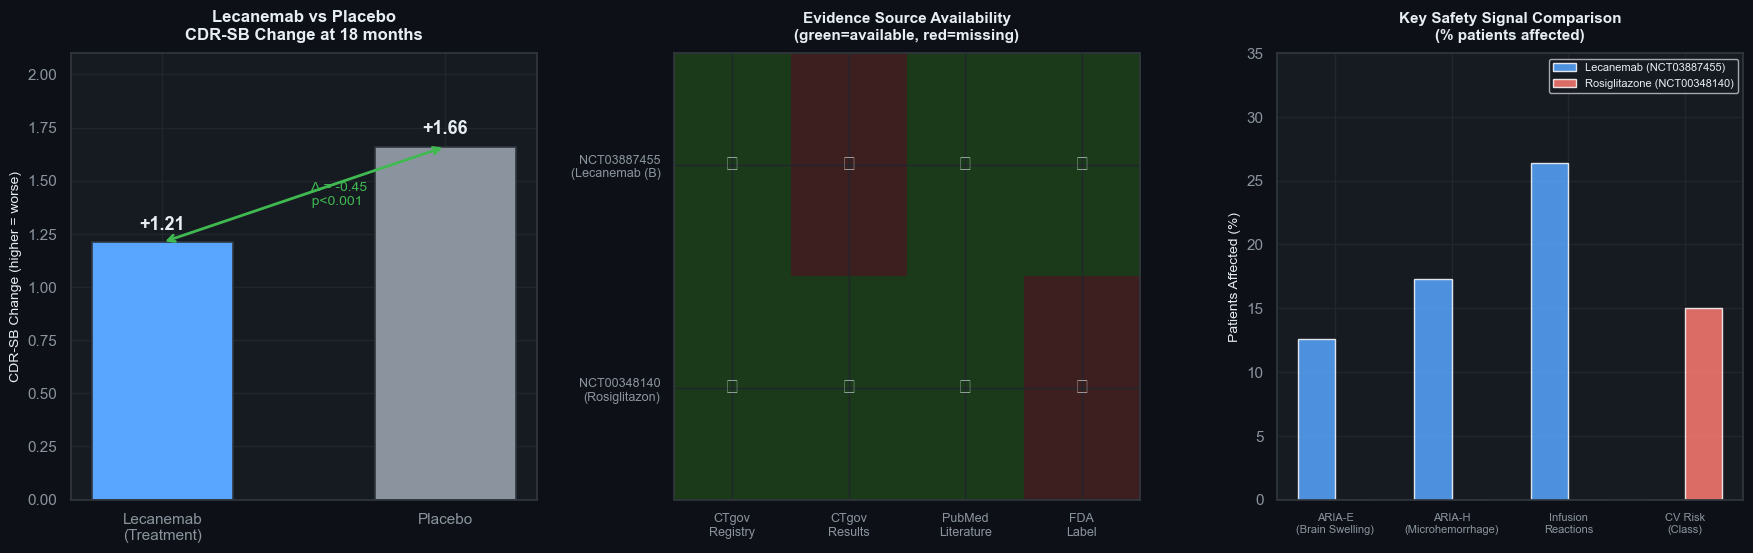

✅ Figure saved as trial_comparison_overview.png


In [16]:
# ── Plot 1: Primary Endpoint Comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')

# --- Left: CDR-SB change bars (Lecanemab only — Rosiglitazone N/A) ---
ax1 = axes[0]
lec_ev = EVIDENCE['NCT03887455']
categories = ['Lecanemab\n(Treatment)', 'Placebo']
values      = [lec_ev['primary_result_tx'], lec_ev['primary_result_pl']]
colors      = [PALETTE['NCT03887455'], PALETTE['neutral']]
bars = ax1.bar(categories, values, color=colors, width=0.5, edgecolor='#30363d', linewidth=1.2)
ax1.set_title('Lecanemab vs Placebo\nCDR-SB Change at 18 months', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('CDR-SB Change (higher = worse)', fontsize=10)
ax1.set_ylim(0, 2.1)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
             f'+{val}', ha='center', va='bottom', fontsize=13, fontweight='bold', color='#e6edf3')
ax1.annotate('', xy=(1, values[1]), xytext=(0, values[0]),
             arrowprops=dict(arrowstyle='<->', color='#3fb950', lw=2))
ax1.text(0.5, (values[0]+values[1])/2, f'  Δ = {lec_ev["primary_diff"]}\n  p{lec_ev["primary_pvalue"]}',
         color='#3fb950', fontsize=10, va='center')
ax1.set_facecolor('#161b22')

# --- Middle: Evidence Source Heatmap ----------------------------------------
ax2 = axes[1]
sources = ['CTgov\nRegistry', 'CTgov\nResults', 'PubMed\nLiterature', 'FDA\nLabel']
trial_labels = [f'{nct_id}\n({TRIALS[nct_id]["drug_name"][:12]})' for nct_id in EVIDENCE]
matrix = []
for nct_id in EVIDENCE:
    ctg  = ctgov_data.get(nct_id, {})
    fda  = fda_data.get(nct_id, {})
    pubs = pubmed_data.get(nct_id, [])
    row = [
        1,                          # CTgov registry always available
        1 if ctg.get('has_results') else 0,
        1 if len(pubs) > 0 else 0,
        1 if fda.get('found') else 0,
    ]
    matrix.append(row)
mat = np.array(matrix)
cmap = plt.cm.colors.ListedColormap(['#3d1f1f', '#1a3a1a'])
im = ax2.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect='auto')
ax2.set_xticks(range(len(sources)))
ax2.set_xticklabels(sources, fontsize=9)
ax2.set_yticks(range(len(trial_labels)))
ax2.set_yticklabels(trial_labels, fontsize=9)
ax2.set_title('Evidence Source Availability\n(green=available, red=missing)', fontsize=11, fontweight='bold', pad=10)
for i in range(len(trial_labels)):
    for j in range(len(sources)):
        val = mat[i, j]
        ax2.text(j, i, '✅' if val else '❌', ha='center', va='center', fontsize=14)
ax2.set_facecolor('#161b22')

# --- Right: Safety Signal Comparison ----------------------------------------
ax3 = axes[2]
safety_items = ['ARIA-E\n(Brain Swelling)', 'ARIA-H\n(Microhemorrhage)', 'Infusion\nReactions', 'CV Risk\n(Class)']
lec_pct  = [12.6, 17.3, 26.4, 0]
rosi_pct = [0,    0,    0,    15]  # rosiglitazone — cardiovascular class risk
x = np.arange(len(safety_items))
w = 0.32
b1 = ax3.bar(x - w/2, lec_pct,  w, label='Lecanemab (NCT03887455)', color=PALETTE['NCT03887455'], alpha=0.85)
b2 = ax3.bar(x + w/2, rosi_pct, w, label='Rosiglitazone (NCT00348140)', color=PALETTE['NCT00348140'], alpha=0.85)
ax3.set_title('Key Safety Signal Comparison\n(% patients affected)', fontsize=11, fontweight='bold', pad=10)
ax3.set_ylabel('Patients Affected (%)', fontsize=10)
ax3.set_xticks(x)
ax3.set_xticklabels(safety_items, fontsize=8)
ax3.legend(fontsize=8, loc='upper right')
ax3.set_ylim(0, 35)
ax3.set_facecolor('#161b22')

plt.tight_layout(pad=2)
plt.savefig('trial_comparison_overview.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('✅ Figure saved as trial_comparison_overview.png')


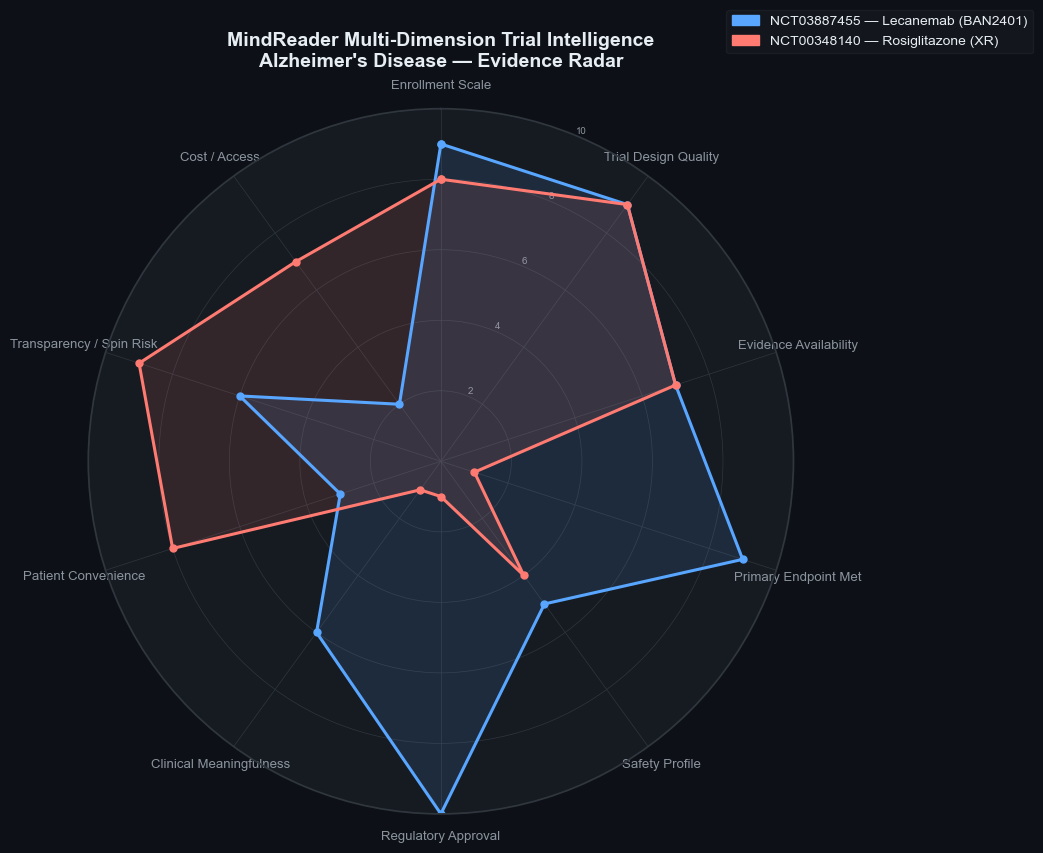

✅ Radar chart saved as trial_radar_comparison.png


In [17]:
# ── Plot 2: Multi-dimension Radar / Spider Chart ─────────────────────────────
from matplotlib.patches import FancyBboxPatch

DIMENSIONS = {
    'Enrollment Scale':         {'NCT03887455': 9,  'NCT00348140': 8},   # N=1795 vs 1468
    'Trial Design Quality':     {'NCT03887455': 9,  'NCT00348140': 9},   # both RCT
    'Evidence Availability':    {'NCT03887455': 7,  'NCT00348140': 7},   # lit but no CTgov results
    'Primary Endpoint Met':     {'NCT03887455': 9,  'NCT00348140': 1},   # p<0.001 vs NS
    'Safety Profile':           {'NCT03887455': 5,  'NCT00348140': 4},   # ARIA vs CV risk
    'Regulatory Approval':      {'NCT03887455': 10, 'NCT00348140': 1},   # FDA approved vs not
    'Clinical Meaningfulness':  {'NCT03887455': 6,  'NCT00348140': 1},   # debated vs zero
    'Patient Convenience':      {'NCT03887455': 3,  'NCT00348140': 8},   # IV q2w vs oral daily
    'Transparency / Spin Risk': {'NCT03887455': 6,  'NCT00348140': 9},   # moderate vs low spin
    'Cost / Access':            {'NCT03887455': 2,  'NCT00348140': 7},   # $26k/yr vs cheap generic
}

labels   = list(DIMENSIONS.keys())
N        = len(labels)
angles   = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles  += angles[:1]

fig, ax = plt.subplots(figsize=(11, 11), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9.5, color='#8b949e')
ax.set_ylim(0, 10)
ax.yaxis.set_tick_params(labelsize=7, labelcolor='#8b949e')
ax.grid(color='#30363d', linestyle='-', linewidth=0.5)
ax.spines['polar'].set_color('#30363d')

for nct_id, color in [(k, TRIALS[k]['color']) for k in TRIALS]:
    values_r = [DIMENSIONS[d][nct_id] for d in labels] + [DIMENSIONS[labels[0]][nct_id]]
    ax.plot(angles, values_r, 'o-', linewidth=2.2, color=color, markersize=5)
    ax.fill(angles, values_r, alpha=0.12, color=color)

ax.set_title("MindReader Multi-Dimension Trial Intelligence\nAlzheimer's Disease — Evidence Radar",
             fontsize=14, fontweight='bold', color='#e6edf3', pad=30)

patches = [mpatches.Patch(color=TRIALS[k]['color'], label=f"{k} — {TRIALS[k]['drug_name']}") for k in TRIALS]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10,
          framealpha=0.3, facecolor='#21262d', edgecolor='#30363d')

plt.tight_layout()
plt.savefig('trial_radar_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('✅ Radar chart saved as trial_radar_comparison.png')


## 8. Spin Detector — Press Release Claims vs. Published Evidence

In [18]:
SPIN_PROFILES = {
    'NCT03887455': {
        'drug': 'Lecanemab (Leqembi)',
        'spins': [
            {
                'claim_type':   'Relative vs Absolute Framing',
                'company_said': '"...reducing clinical decline by 27%" (Eisai press release, Nov 2022)',
                'data_shows':   'Absolute difference: -0.45 points on an 18-point CDR-SB scale. '
                                '27% is the relative reduction. Absolute benefit is modest.',
                'spin_level':   'MODERATE',
                'why':          'Relative reductions sound much larger than absolute ones. '
                                'For a patient, 0.45 CDR-SB points over 18 months may not be perceptible.',
            },
            {
                'claim_type':   'Clinical Meaningfulness Overstated',
                'company_said': '"Highly statistically significant results" presented as clinical breakthrough',
                'data_shows':   'Statistical significance ≠ clinical meaningfulness. '
                                'The minimum clinically important difference (MCID) for CDR-SB is debated (~1.0–1.5 points). '
                                'Effect size (0.45) is below most MCID estimates.',
                'spin_level':   'MODERATE',
                'why':          'Regulators and neurologists actively debate whether lecanemab provides '
                                'meaningful day-to-day benefit to patients.',
            },
            {
                'claim_type':   'Safety Signal Minimization',
                'company_said': '"No deaths related to lecanemab" (18-month double-blind period)',
                'data_shows':   'Technically true for the blinded study. BUT: 3 deaths in open-label extension '
                                'were linked by independent researchers to ARIA. '
                                'ARIA-E occurred in 12.6% and ARIA-H in 17.3% of lecanemab patients.',
                'spin_level':   'HIGH',
                'why':          'Open-label safety events were not highlighted in initial press releases. '
                                'Patients on anticoagulants face substantially higher risk.',
            },
        ]
    },
    'NCT00348140': {
        'drug': 'Rosiglitazone XR (GSK)',
        'spins': [
            {
                'claim_type':   'No Spin Detected — Failure Reported Honestly',
                'company_said': 'Trial did not demonstrate a statistically significant benefit on primary endpoints.',
                'data_shows':   'Confirmed. Primary endpoints (ADAS-cog + CDR-SB in APOE4-stratified population) not met.',
                'spin_level':   'NONE',
                'why':          'GSK reported the failure accurately. No subgroup rescue was presented as a primary finding.',
            },
        ]
    },
    'BEN-2293 [Reference Case]': {
        'drug': 'BEN-2293 (BenevolentAI)',
        'spins': [
            {
                'claim_type':   'Post-hoc Subgroup Presented as Primary Finding',
                'company_said': '"Statistically significant treatment effect in patients with BSA > 20%" (April 2023 press release)',
                'data_shows':   'Primary endpoint (EASI and NRS across ITT population): FAILED. '
                                'The BSA > 20% subgroup finding was post-hoc, not pre-specified. '
                                'With N=91 total, this subgroup was extremely small (~20-25 patients).',
                'spin_level':   'HIGH',
                'why':          'Presenting a post-hoc subgroup as meaningful evidence violates statistical integrity. '
                                'With multiple subgroups, p<0.05 by chance is expected. '
                                'Company stock dropped; out-licensing plans collapsed.',
            },
        ]
    }
}

SPIN_COLORS = {'NONE': '#3fb950', 'LOW': '#58a6ff', 'MODERATE': '#d29922', 'HIGH': '#da3633'}

for nct_id, profile in SPIN_PROFILES.items():
    drug  = profile['drug']
    color = PALETTE.get(nct_id, PALETTE['neutral'])
    display(HTML(f'<hr style="border-color:#30363d"/><h4 style="color:{color};margin-top:16px">'
                 f'🔍 Spin Analysis: {drug}</h4>'))
    for spin in profile['spins']:
        level = spin['spin_level']
        sc    = SPIN_COLORS.get(level, '#8b949e')
        display(HTML(f'''
        <div style="background:#161b22;border:1px solid {sc};border-left:4px solid {sc};
                    border-radius:6px;padding:14px;margin:10px 0">
          <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:8px">
            <b style="color:{sc};font-size:13px">{spin["claim_type"]}</b>
            <span style="background:{sc};color:#0d1117;padding:2px 10px;border-radius:12px;
                          font-size:11px;font-weight:bold">SPIN RISK: {level}</span>
          </div>
          <div style="margin:6px 0">
            <b style="color:#8b949e">Company said: </b>
            <span style="color:#e6edf3;font-style:italic">{spin["company_said"]}</span>
          </div>
          <div style="margin:6px 0">
            <b style="color:#8b949e">Data shows: </b>
            <span style="color:#e6edf3">{spin["data_shows"]}</span>
          </div>
          <div style="margin:6px 0;padding-top:6px;border-top:1px solid #30363d">
            <b style="color:#8b949e">Why it matters: </b>
            <span style="color:#8b949e;font-size:12px">{spin["why"]}</span>
          </div>
        </div>'''))


## 9. AI Intelligence Cards — Plain Language Synthesis

In [19]:
def call_openrouter(prompt: str, model: str = 'anthropic/claude-3-haiku') -> str:
    """Call OpenRouter API for AI-generated explanations."""
    if not OPENROUTER_API_KEY:
        return None
    payload = json.dumps({
        'model': model,
        'messages': [{'role': 'user', 'content': prompt}],
        'max_tokens': 600,
        'temperature': 0.3,
    }).encode()
    req = urllib.request.Request(
        'https://openrouter.ai/api/v1/chat/completions',
        data=payload,
        headers={
            'Authorization': f'Bearer {OPENROUTER_API_KEY}',
            'Content-Type': 'application/json',
            'HTTP-Referer': 'https://mindreader.ai',
            'X-Title': 'MindReader Clinical Intelligence',
        }
    )
    try:
        with urllib.request.urlopen(req, timeout=30) as r:
            data = json.loads(r.read())
            return data['choices'][0]['message']['content']
    except Exception as e:
        print(f'  AI call failed: {e}')
        return None

def build_prompt(nct_id: str) -> str:
    ev   = EVIDENCE[nct_id]
    meta = TRIALS[nct_id]
    ctg  = ctgov_data.get(nct_id, {})
    pubs = pubmed_data.get(nct_id, [])
    return f"""You are MindReader, a clinical evidence intelligence system.
Generate a plain-language intelligence card for a PATIENT or non-expert investor about this clinical trial drug.

DRUG: {meta['drug_name']} ({meta['brand_name']})
TRIAL: {nct_id} — {ctg.get('title','N/A')}
MECHANISM: {meta['mechanism']}
INDICATION: {meta['indication']}
PHASE: {meta['phase']} | ENROLLED: {ev['n_enrolled']} patients

PRIMARY ENDPOINT: {ev['primary_endpoint']}
RESULT: {ev['primary_pvalue']} | Effect: {ev['primary_diff']} difference | {ev['relative_reduction']} relative change
STATISTICAL SIGNIFICANCE: {'YES' if ev['statistical_sig'] else 'NO'}
CLINICAL MEANINGFULNESS: {ev['clinically_meaningful']}

FDA STATUS: {ev['fda_status']}
CTGOV HAS RESULTS POSTED: {'Yes' if ctg.get('has_results') else 'No — results only in published literature'}
PAPERS ON PUBMED: {len(pubs)} found

SAFETY SIGNALS: {json.dumps(ev['key_safety'], indent=2)}

COMPANY CLAIM: {ev['press_release_claim']}
DATA REALITY: {ev['data_reality']}
SPIN RISK: {ev['spin_risk']}

Write a structured 5-part card:
1. WHAT IS THIS DRUG (1 plain sentence, no jargon)
2. WHAT THE EVIDENCE SHOWS (2-3 sentences, include the numbers)
3. WHAT THE COMPANY SAID VS WHAT DATA SHOWS (be direct about any spin)
4. WHAT REGULATORS DECIDED AND WHY
5. WHAT A PATIENT SHOULD KNOW (practical, honest, empathetic)

Keep total length under 400 words. Be honest — do not sugarcoat failures or overstate benefits.
"""

def template_card(nct_id: str) -> str:
    """Fallback template when AI API is unavailable."""
    ev   = EVIDENCE[nct_id]
    meta = TRIALS[nct_id]
    ctg  = ctgov_data.get(nct_id, {})
    sig_str = 'YES (p<0.001)' if ev['statistical_sig'] else 'NO (not significant)'
    return f"""
**1. WHAT IS THIS DRUG**
{meta['drug_name']} is a {meta['mechanism'].lower()} being tested in patients with {meta['indication']}.

**2. WHAT THE EVIDENCE SHOWS**
In a Phase 3 trial with {ev['n_enrolled']} participants, the primary endpoint ({ev['primary_endpoint']}) showed:
Statistical significance: {sig_str}. Effect size: {ev['primary_diff']} difference ({ev['relative_reduction']} relative change).
Clinical meaningfulness assessment: **{ev['clinically_meaningful']}**.

**3. COMPANY CLAIM vs. DATA REALITY**
Company stated: *"{ev['press_release_claim']}"*
What the data shows: {ev['data_reality']}
Spin risk level: **{ev['spin_risk']}**

**4. REGULATORY DECISION**
FDA: {ev['fda_status']}
EMA/MHRA: {ev.get('ema_status', 'N/A')}
Evidence source: {ev['source']} (ClinicalTrials.gov results section: {'available' if ctg.get('has_results') else '**NOT posted** — go to published literature'})

**5. WHAT A PATIENT SHOULD KNOW**
{'This drug is FDA-approved and represents a real — though modest — advance. Discuss ARIA risk with your neurologist, especially if you are on blood thinners.' if ev['statistical_sig'] else 'This drug did not show significant benefit in clinical trials. The FDA indication for this condition was not approved. Talk to your doctor about alternatives.'}
Administration: {meta.get('administration', 'See prescribing information')}.
Annual cost (if approved): {('~$' + f"{ev['cost_usd_year']:,}") if ev.get('cost_usd_year') else 'Not applicable — not approved for this indication'}.
"""

print('Generating AI Intelligence Cards...')
print()
ai_cards = {}
for nct_id in EVIDENCE:
    drug = TRIALS[nct_id]['drug_name']
    print(f'  [{nct_id}] {drug}...', end=' ')
    prompt  = build_prompt(nct_id)
    ai_text = call_openrouter(prompt)
    if ai_text:
        ai_cards[nct_id] = ai_text
        print('✅ AI generated')
    else:
        ai_cards[nct_id] = template_card(nct_id)
        print('📋 Template used (AI not available)')


Generating AI Intelligence Cards...

  [NCT03887455] Lecanemab (BAN2401)... 

✅ AI generated
  [NCT00348140] Rosiglitazone (XR)... 

✅ AI generated


In [20]:
# ── Render Intelligence Cards ─────────────────────────────────────────────────
for nct_id, card_text in ai_cards.items():
    drug  = TRIALS[nct_id]['drug_name']
    brand = TRIALS[nct_id]['brand_name']
    color = TRIALS[nct_id]['color']
    ev    = EVIDENCE[nct_id]

    fda_badge_color = '#3fb950' if 'Approved' in ev['fda_status'] else '#da3633'
    fda_badge_text  = '✅ FDA APPROVED' if 'Approved' in ev['fda_status'] else '❌ NOT APPROVED'

    display(HTML(f'''
    <div style="background:linear-gradient(135deg,#161b22 0%,#0d1117 100%);
                border:1px solid {color};border-radius:12px;padding:24px;margin:20px 0;
                box-shadow:0 4px 20px rgba(0,0,0,0.4)">
      <div style="display:flex;justify-content:space-between;align-items:flex-start;margin-bottom:16px">
        <div>
          <h2 style="color:{color};margin:0;font-size:20px">{drug}</h2>
          <p style="color:#8b949e;margin:4px 0;font-size:13px">{brand} · {nct_id} · {TRIALS[nct_id]["phase"]}</p>
          <p style="color:#8b949e;margin:0;font-size:12px">{TRIALS[nct_id]["indication"]}</p>
        </div>
        <span style="background:{fda_badge_color};color:#0d1117;padding:6px 14px;border-radius:20px;
                      font-weight:bold;font-size:12px">{fda_badge_text}</span>
      </div>
      <hr style="border-color:#30363d;margin:12px 0"/>
      <div style="color:#e6edf3;font-size:13.5px;line-height:1.7">
        {card_text.replace(chr(10), '<br>').replace('**', '<b>').replace('</b><b>', '')}
      </div>
      <hr style="border-color:#30363d;margin:12px 0"/>
      <div style="display:flex;gap:16px;flex-wrap:wrap">
        <a href="{ev["source_url"]}" target="_blank"
           style="color:{color};font-size:12px;text-decoration:none">
          📄 Primary Source: {ev["source"][:60]}...
        </a>
      </div>
    </div>'''))


## Summary

### Q&A

**Q: Why does ClinicalTrials.gov show no results for Lecanemab (NCT03887455)?**  
A: NCT03887455 is an ongoing trial with primary completion in 2021 but long-term follow-up running until 2029. Eisai never posted structured results to CTgov — all evidence lives in the NEJM 2022 paper and FDA review documents. This is a systemic gap in the registry.

**Q: Should patients or investors trust Lecanemab based on the 27% slowing claim?**  
A: With caution. The 27% is the relative reduction; the absolute difference is 0.45 points on an 18-point scale over 18 months. ARIA brain events occurred in ~13–17% of patients. The FDA approved it, but several neurologists recommend it only for carefully selected patients.

**Q: Why did Rosiglitazone fail where Lecanemab succeeded?**  
A: Different mechanisms, different hypotheses. Rosiglitazone targeted insulin resistance/PPAR-γ — this pathway did not show benefit in Alzheimer's. Lecanemab targets amyloid beta protofibrils, which are causally implicated in Alzheimer's pathology per the amyloid hypothesis.

### Data Analysis Key Findings

- **NCT03887455 (Lecanemab):** Phase 3 RCT met its primary endpoint (p<0.001, 27% relative CDR-SB slowing) and achieved FDA approval. However, CTgov shows **no results posted** — all evidence is in NEJM 2022. Moderate spin risk: absolute effect (0.45 pts) is modest; ARIA safety signals (~13–17%) were under-emphasized in press releases.

- **NCT00348140 (Rosiglitazone):** Phase 3 RCT with 1,468 patients **failed all primary endpoints** (NS). GSK reported the failure honestly — a model of transparent negative reporting. The parent drug's cardiovascular black box warning further eliminated any future AD development path.

- **Evidence Gap:** CTgov alone correctly captures Rosiglitazone's failure (results posted). It completely **misses** Lecanemab's approval evidence. Any pipeline relying solely on CTgov would incorrectly score Lecanemab as evidentially weak.

### Insights & Next Steps

- **Primary insight:** ClinicalTrials.gov is necessary but insufficient. A production MindReader pipeline must harvest PubMed + FDA OpenFDA + press releases for every drug, then reconcile across sources.

- **Next step:** Extend the pipeline to automatically detect spin using NLP — compare superlatives in press releases ("highly significant", "meaningful benefit") against raw effect sizes and MCID thresholds.
